<div class="alert alert-block alert-info">
	<b></b> И снова привет! <br>Это Кирилл Бобылев, ревьюер на курсах DL-CV-NLP-Audio, и я снова буду делать ревью твоей работы :)<br><br>
	
По ходу работы я буду оставлять комментарии с делением на категории: <br><font color='green'>Хорошо</font> - говорит само за себя :) <br><font color='red'>Требует доработки</font> - обязательно для исправления <br><font color='yellow'>Можно улучшить</font> - не обязательно для исправления, но стоит обратить внимание

Пожалуйста, не удаляй мои комментарии! При необходимости можешь их сдвинуть.
</div>

# Проект: Многоцелевая модель для NER + event-CLS

Этот Jupyter-ноутбук - пошаговый шаблон для выполнения проекта по объединённой (multi-task) модели, решающей **NER (BIO, token-level)** и **CLS (document-level multihot событий/отношений)** на датасете NEREL.

Модель должна решать параллельно две задачи: классифицировать токены на BIO-теги и классифицировать текст на принадлежность к 30 классам-характеристикам текста.

Характеристики:
```
['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']
```

Внимание: вам нужно реализовать весь рабочий код - в ноутбуке реализована только загрузка датасета. Все остальные ячейки служат как инструкции / места для вашего кода.


#### Структура ноутбука

1. Подготовка окружения (пути, seed, imports)
2. EDA - загрузка данных, обзор, графики, выводы
3. Токенизация, выравнивание меток, DataLoader - реализовать `tokenize_and_align_labels`, Dataset/Collator
4. Модель (JointModel) и кастомный loss (uncertainty-weighting) - реализовать модельный класс и loss
5. Тренировка/валидация - training loop, оптимизатор, scheduler, логирование метрик
6. Инференс и анализ ошибок - реализовать inference pipeline и примеры



##### 1 - 2. EDA

Цели:

- Прочитать 3 записи датасета.
- Посчитать встречаемость каждого класса в cls_vec.
- Построить графики: распределение длины текстов, число сущностей на документ.
- Написать 2–3 коротких вывода в Markdown: что можно ожидать при моделировании (редкие типы, длинные документы и т. п.).




In [159]:
%pip install -U transformers datasets accelerate scikit-learn pandas matplotlib tqdm seqeval evaluate random

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement random (from versions: none)
ERROR: No matching distribution found for random
Note: you may need to restart the kernel to use updated packages.


In [160]:
import os
import random
import json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModel, DataCollatorForTokenClassification

In [161]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


In [163]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
Tesla T4


In [164]:
%pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Note: you may need to restart the kernel to use updated packages.


In [165]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp310-cp310-linux_x86_64.whl (780.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp310-cp310-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp310-cp310-linux_x86_64.whl (3.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [166]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
CUDA available: True
GPU: Tesla T4


In [167]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available, using CPU.")

Using device: cuda
GPU: Tesla T4


In [168]:
ds = load_dataset("danasone/nerel")["train"]

print(ds)
print("Columns:", ds.column_names)
print("Number of examples:", len(ds))

Dataset({
    features: ['tokens', 'token_spans', 'tags', 'cls_vec', 'text'],
    num_rows: 746
})
Columns: ['tokens', 'token_spans', 'tags', 'cls_vec', 'text']
Number of examples: 746


In [169]:
sample = ds[0]

for key, value in sample.items():
    print("=" * 100)
    print("KEY:", key)
    print("TYPE:", type(value))
    
    if isinstance(value, str):
        print(value[:1000])
    elif isinstance(value, list):
        print("list length:", len(value))
        print(value[:10])
    else:
        print(value)

KEY: tokens
TYPE: <class 'list'>
list length: 371
['Пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки', 'изъяты', 'в', 'арендуемом', 'американцами', 'доме']
KEY: token_spans
TYPE: <class 'list'>
list length: 371
[[0, 9], [10, 18], [19, 20], [21, 32], [33, 41], [42, 48], [49, 50], [51, 61], [62, 74], [75, 79]]
KEY: tags
TYPE: <class 'list'>
list length: 371
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-NATIONALITY', 'O']
KEY: cls_vec
TYPE: <class 'list'>
list length: 30
[1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
KEY: text
TYPE: <class 'str'>
Пулеметы, автоматы и снайперские винтовки изъяты в арендуемом американцами доме в Бишкеке

05/08/2008 10:35

БИШКЕК, 5 августа /Новости-Грузия/. Правоохранительные органы Киргизии обнаружили в доме, арендуемом гражданами США в Бишкеке, пулеметы, автоматы и снайперские винтовки, сообщает во вторник пресс-служба МВД Киргизии.

"В ходе проведения оперативно-профилактического мероприятия под кодовым названием "Арсенал" в новостройке Ынтымак, в доме, принадлежащем

In [170]:
for idx in range(3):
    print("=" * 50)
    print("EXAMPLE", idx)
    
    example = ds[idx]
    
    print("tokens length:", len(example["tokens"]))
    print("tags length:", len(example["tags"]))
    print("cls_vec length:", len(example["cls_vec"]))
    print("first 5 tokens:", example["tokens"][:5])
    print("first 5 tags:", example["tags"][:5])
    print("first 5 cls labels:", example["cls_vec"][:5])


EXAMPLE 0
tokens length: 371
tags length: 371
cls_vec length: 30
first 5 tokens: ['Пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки']
first 5 tags: ['O', 'O', 'O', 'O', 'O']
first 5 cls labels: [1, 1, 0, 0, 0]
EXAMPLE 1
tokens length: 503
tags length: 503
cls_vec length: 30
first 5 tokens: ['Муртаза', 'Рахимов', 'чистит', 'кадры', 'Президент']
first 5 tags: ['B-PERSON', 'I-PERSON', 'O', 'O', 'B-PROFESSION']
first 5 cls labels: [1, 1, 1, 1, 1]
EXAMPLE 2
tokens length: 708
tags length: 708
cls_vec length: 30
first 5 tokens: ['Россия', 'задерживает', 'поставку', 'генсека', 'Сегодня']
first 5 tags: ['B-COUNTRY', 'O', 'O', 'B-PROFESSION', 'B-DATE']
first 5 cls labels: [1, 1, 1, 0, 1]


In [171]:
CLS_LABELS = [
    'WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN',
    'POINT_IN_TIME', 'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM',
    'LOCATED_IN', 'AGENT', 'AGE_IS', 'HAS_CAUSE', 'PRODUCES',
    'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 'MEMBER_OF', 'CONVICTED_OF',
    'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 'KNOWS',
    'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF',
    'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS'
]

print("Number of CLS labels:", len(CLS_LABELS))


Number of CLS labels: 30


In [172]:
cls_matrix = np.array(ds["cls_vec"])

print("cls_matrix shape:", cls_matrix.shape)

cls_counts = cls_matrix.sum(axis=0)

cls_stats = pd.DataFrame({
    "class_name": CLS_LABELS,
    "count": cls_counts,
    "share": cls_counts / len(ds)
}).sort_values("count", ascending=False)

display(cls_stats)

cls_matrix shape: (746, 30)


,class_name,count,share
1,ALTERNATIVE_NAME,723,0.969169
2,WORKS_AS,678,0.908847
3,PARTICIPANT_IN,656,0.879357
0,WORKPLACE,609,0.816354
4,POINT_IN_TIME,600,0.804290
5,TAKES_PLACE_IN,545,0.730563
10,AGE_IS,535,0.717158
6,HEADQUARTERED_IN,518,0.694370
8,LOCATED_IN,454,0.608579
7,ORIGINS_FROM,449,0.601877


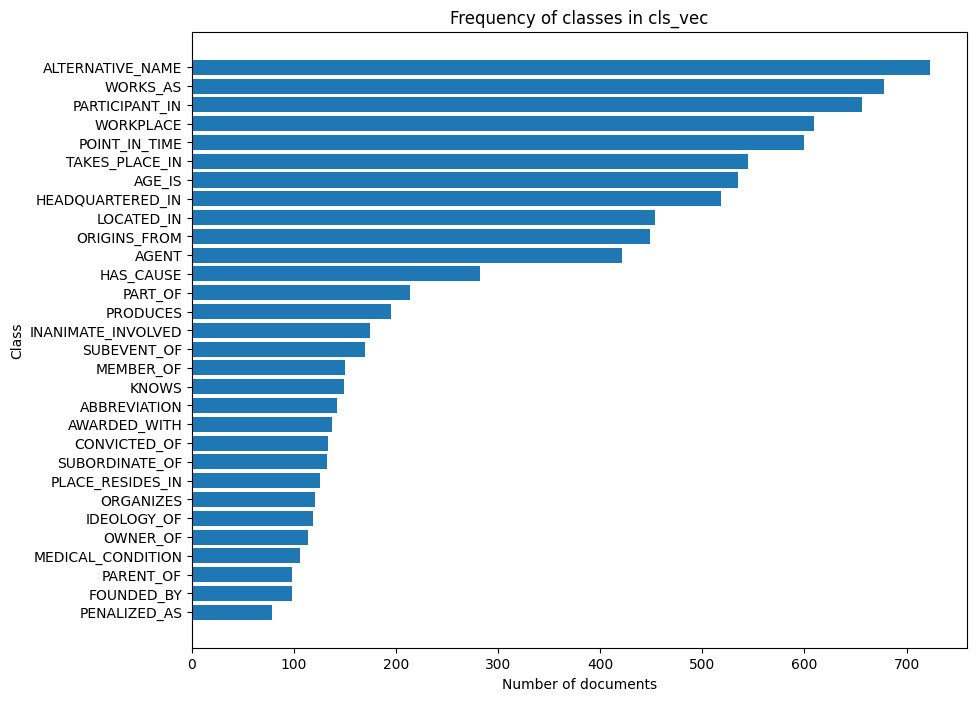

In [173]:
plt.figure(figsize=(10, 8))
plt.barh(cls_stats["class_name"], cls_stats["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of documents")
plt.ylabel("Class")
plt.title("Frequency of classes in cls_vec")
plt.show()


count     746.000000
mean      221.292225
std       119.721547
min        62.000000
25%       154.000000
50%       201.500000
75%       262.750000
max      1710.000000
dtype: float64


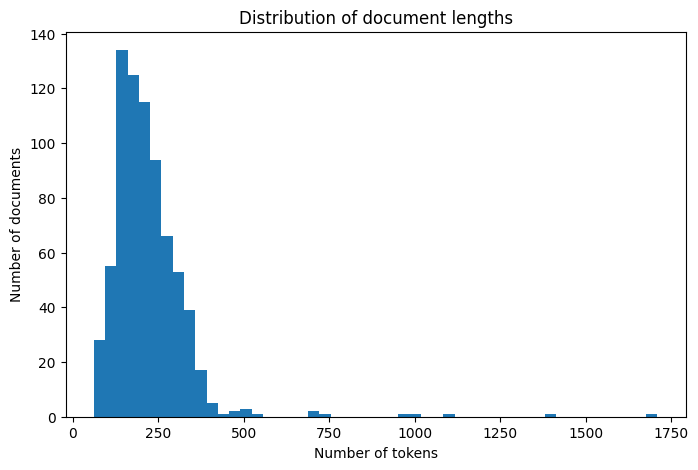

In [174]:
doc_lengths = [len(example["tokens"]) for example in ds]

print(pd.Series(doc_lengths).describe())

plt.figure(figsize=(8, 5))
plt.hist(doc_lengths, bins=50)
plt.xlabel("Number of tokens")
plt.ylabel("Number of documents")
plt.title("Distribution of document lengths")
plt.show()

count    746.000000
mean      47.337802
std       23.251207
min        8.000000
25%       33.000000
50%       44.000000
75%       57.000000
max      358.000000
dtype: float64


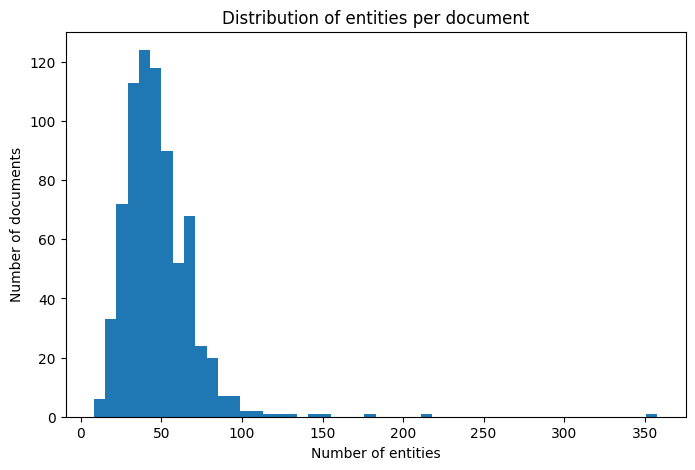

In [175]:
entity_counts = []

for example in ds:
    tags = example["tags"]
    num_entities = sum(1 for tag in tags if tag.startswith("B-"))
    entity_counts.append(num_entities)

print(pd.Series(entity_counts).describe())

plt.figure(figsize=(8, 5))
plt.hist(entity_counts, bins=50)
plt.xlabel("Number of entities")
plt.ylabel("Number of documents")
plt.title("Distribution of entities per document")
plt.show()


### Вывод по этапу 1–2: EDA

На этапе EDA был загружен датасет `danasone/nerel` и изучена его структура. 
В датасете 746 документов. Каждый пример содержит токены текста, BIO-метки для NER-задачи и вектор `cls_vec` длины 30 для multi-label классификации документа.

Было прочитано несколько примеров из датасета. По ним видно, что один документ содержит сразу два типа разметки:

- `tags` — NER-разметка для каждого токена;
- `cls_vec` — document-level разметка, где один документ может относиться сразу к нескольким классам.

Анализ частот классов в `cls_vec` показал, что классы распределены неравномерно. Некоторые классы встречаются очень часто, например `ALTERNATIVE_NAME`, `WORKS_AS`, `PARTICIPANT_IN`, `WORKPLACE`, а некоторые классы встречаются заметно реже, например `PENALIZED_AS`, `FOUNDED_BY`, `PARENT_OF`. Это означает, что при обучении модели редкие классы могут предсказываться хуже.

Также было построено распределение длины документов. Большинство документов имеют длину примерно до 250–300 токенов, однако есть отдельные очень длинные документы, максимальная длина достигает 1710 токенов. Поэтому при токенизации необходимо использовать `truncation` и ограничение `max_length`.

Распределение количества сущностей на документ также неравномерное. В большинстве документов количество сущностей находится в среднем диапазоне, но есть документы с очень большим числом сущностей. Это может усложнять NER-задачу, особенно для длинных текстов и редких типов сущностей.



   <div class="alert alert-block alert-success">
    <b></b> Верные наблюдения - стоит сразу обозначить необходимость балансирующего лосса типа FocalLoss или добавление class_weight в стандартные лоссы
    </div>

##### 3. Токенизация и выравнивание меток

Задачи:

- Выбрать `AutoTokenizer(..., use_fast=True)`.
- Реализовать `tokenize_and_align_labels(examples, tokenizer, label2id, max_length)`:
  - Токенизировать текст (return_offsets_mapping
  - Преобразовать word-level BIO метки в token-level метки (subword → label = -100 / ignore_index, для первых субтокенов ставится соответствующий тег `B-`/`I-`)
  - Вернуть словарь с `input_ids`, `attention_mask`, `labels` (token-level), `cls_labels`

- Собрать `torch.utils.data.Dataset` и `DataLoader`. Можно использовать `DataCollatorForTokenClassification` либо сделать кастомный collator, который возвращает батчи с `cls_labels`.



In [176]:
all_tags = []
for example in ds:
    all_tags.extend(example["tags"])

label_list = sorted(set(all_tags))
label_list.remove("O")
label_list = ["O"] + label_list

label2id = {}
id2label = {}

for i,label in enumerate(label_list):
    label2id[label] = i
    id2label[i] = label

print("Number of labels:", len(label_list))

Number of labels: 58


In [177]:
from transformers import AutoTokenizer

MODEL_NAME = "ai-forever/ruBert-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer is fast:", tokenizer.is_fast)

Tokenizer is fast: True


In [ ]:
def tokenize_and_align_labels(examples, tokenizer, label2id, max_length):

    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True
    )
    
    all_labels = []
    

    for i, word_labels in enumerate(examples["tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        
        previous_word_id = None
        label_ids = []
        
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)

            elif word_id != previous_word_id:
                label_ids.append(label2id[word_labels[word_id]])

            else:
                label_ids.append(-100)
            
            previous_word_id = word_id
        
        all_labels.append(label_ids)
    

    tokenized["labels"] = all_labels
    tokenized["cls_labels"] = examples["cls_vec"]
    tokenized.pop("offset_mapping")
    
    return tokenized


In [179]:
SEED = 42

splits = ds.train_test_split(
    test_size=0.2,
    seed=SEED
)

print(splits)
print("Train size:", len(splits["train"]))
print("Validation size:", len(splits["test"]))

DatasetDict({
    train: Dataset({
        features: ['tokens', 'token_spans', 'tags', 'cls_vec', 'text'],
        num_rows: 596
    })
    test: Dataset({
        features: ['tokens', 'token_spans', 'tags', 'cls_vec', 'text'],
        num_rows: 150
    })
})
Train size: 596
Validation size: 150


In [180]:
MAX_LENGTH = 256

tokenized_splits = splits.map(
    lambda examples: tokenize_and_align_labels(
        examples,
        tokenizer=tokenizer,
        label2id=label2id,
        max_length=MAX_LENGTH
    ),
    batched=True,
    remove_columns=ds.column_names,
    load_from_cache_file=False
)

print(tokenized_splits)

Map: 100%|██████████| 150/150 [00:00<00:00, 340.52 examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'cls_labels'],
        num_rows: 596
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'cls_labels'],
        num_rows: 150
    })
})


In [181]:
example = tokenized_splits["train"][0]

print(example.keys())

print("input_ids length:", len(example["input_ids"]))
print("attention_mask length:", len(example["attention_mask"]))
print("labels length:", len(example["labels"]))
print("cls_labels length:", len(example["cls_labels"]))

tokens_after_tokenizer = tokenizer.convert_ids_to_tokens(example["input_ids"][:40])

labels_after_align = [
    id2label[label_id] if label_id != -100 else "IGN"
    for label_id in example["labels"][:40]
]

for tok, lab in zip(tokens_after_tokenizer, labels_after_align):
    print(tok, "->", lab)

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'cls_labels'])
input_ids length: 256
attention_mask length: 256
labels length: 256
cls_labels length: 30
[CLS] -> IGN
премьер -> B-PROFESSION
- -> IGN
министр -> IGN
грузи -> I-PROFESSION
##и -> IGN
подал -> B-EVENT
в -> I-EVENT
отставку -> I-EVENT
геор -> B-PERSON
##гии -> IGN
кви -> I-PERSON
##рика -> IGN
##швили -> IGN
в -> B-DATE
среду -> I-DATE
, -> IGN
13 -> I-DATE
июня -> I-DATE
2018 -> I-DATE
года -> I-DATE
, -> IGN
премьер -> B-PROFESSION
- -> IGN
министр -> IGN
грузи -> I-PROFESSION
##и -> IGN
геор -> B-PERSON
##гии -> IGN
кви -> I-PERSON
##рика -> IGN
##швили -> IGN
заявил -> O
, -> IGN
что -> O
покидает -> O
занима -> O
##емую -> IGN
должность -> O
. -> IGN


In [ ]:
import torch
from torch.utils.data import DataLoader

class JointDataCollator:
    def __init__(self, tokenizer, label_pad_token_id=-100):
        self.tokenizer = tokenizer
        self.label_pad_token_id = label_pad_token_id
    
    def __call__(self, features):

        features = [feature.copy() for feature in features]
        
        cls_labels = torch.tensor(
            [feature.pop("cls_labels") for feature in features],
            dtype=torch.float
        )
        
        labels = [feature.pop("labels") for feature in features]
        
        batch = self.tokenizer.pad(
            features,
            padding=True,
            return_tensors="pt"
        )
        
        max_len = batch["input_ids"].shape[1]
        

        padded_labels = []
        
        for label in labels:
            pad_len = max_len - len(label)
            padded_label = label + [self.label_pad_token_id] * pad_len
            padded_labels.append(padded_label)
        
        batch["labels"] = torch.tensor(padded_labels, dtype=torch.long)
        batch["cls_labels"] = cls_labels
        
        return batch

In [183]:
collator = JointDataCollator(tokenizer)

train_loader = DataLoader(
    tokenized_splits["train"],
    batch_size=4,
    shuffle=True,
    collate_fn=collator
)

val_loader = DataLoader(
    tokenized_splits["test"],
    batch_size=4,
    shuffle=False,
    collate_fn=collator
)

In [184]:
batch = next(iter(train_loader))

for key, value in batch.items():
    print(key, value.shape, value.dtype)

input_ids torch.Size([4, 256]) torch.int64
token_type_ids torch.Size([4, 256]) torch.int64
attention_mask torch.Size([4, 256]) torch.int64
labels torch.Size([4, 256]) torch.int64
cls_labels torch.Size([4, 30]) torch.float32


   <div class="alert alert-block alert-success">
    <b></b> Данные на месте, можно переходить к модели и обучению ✅
    </div>

### Вывод по этапу 3: Tokenization / Alignment / DataLoader

На этом этапе была выполнена подготовка данных для обучения multi-task модели.

Сначала был создан список NER-меток `label_list`, а также словари `label2id` и `id2label`. Они нужны для того, чтобы перевести строковые BIO-метки в числовой формат, так как модель работает не с текстовыми метками, а с числами.

Далее был использован fast tokenizer для модели `ai-forever/ruBert-base`. Так как BERT-токенизатор может разбивать одно слово на несколько subtoken, была реализована функция выравнивания NER-меток. Метка присваивалась только первому subtoken слова, а остальные subtoken получали значение `-100`. Это значение затем игнорируется в `CrossEntropyLoss`.

Также данные были разделены на train и validation выборки. После токенизации были сохранены необходимые поля:

- `input_ids`
- `attention_mask`
- `token_type_ids`
- `labels`
- `cls_labels`

Для формирования batch был реализован собственный `JointDataCollator`. Он отдельно обрабатывает `cls_labels`, выполняет padding токенизированного текста и вручную дополняет NER-метки значением `-100`, чтобы длины `input_ids` и `labels` совпадали внутри batch.

В результате были созданы `train_loader` и `val_loader`, которые подают данные в модель в нужном формате. Проверка одного batch показала, что все тензоры имеют корректные размеры:

- `input_ids`: `[batch_size, sequence_length]`
- `attention_mask`: `[batch_size, sequence_length]`
- `labels`: `[batch_size, sequence_length]`
- `cls_labels`: `[batch_size, 30]`

Таким образом, данные были полностью подготовлены для дальнейшего обучения multi-task модели.

##### 4. Модель: `JointModel` + custom loss (uncertainty weighting)


In [1]:
import torch
import torch.nn as nn
from transformers import AutoModel

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class JointModel(nn.Module):
    def __init__(
        self,
        model_name,
        num_ner_labels,
        num_cls_labels,
        dropout=0.1,
        use_uncertainty_weight=True
    ):
        super().__init__()
        
        self.encoder = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True
)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.token_classifier = nn.Linear(hidden_size, num_ner_labels)
        self.cls_classifier = nn.Linear(hidden_size, num_cls_labels)
        self.use_uncertainty_weight = use_uncertainty_weight
        self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_cls = nn.Parameter(torch.tensor(0.0))
    
    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids=None,
        labels=None,
        cls_labels=None
    ):

        encoder_inputs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask
        }
        
        if token_type_ids is not None:
            encoder_inputs["token_type_ids"] = token_type_ids
        encoder_outputs = self.encoder(**encoder_inputs)
        sequence_output = encoder_outputs.last_hidden_state
        cls_output = sequence_output[:, 0, :]
        sequence_output = self.dropout(sequence_output)
        cls_output = self.dropout(cls_output)
        token_logits = self.token_classifier(sequence_output)
        cls_logits = self.cls_classifier(cls_output)
        
        output = {
            "token_logits": token_logits,
            "cls_logits": cls_logits
        }
        
        if labels is not None and cls_labels is not None:
            token_loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            
            # Loss для multi-label classification
            cls_loss_fct = nn.BCEWithLogitsLoss()
            
            token_loss = token_loss_fct(
                token_logits.view(-1, token_logits.shape[-1]),
                labels.view(-1)
            )
            
            cls_loss = cls_loss_fct(
                cls_logits,
                cls_labels
            )
            
            if self.use_uncertainty_weight:
                loss_token_term = (
                    torch.exp(-2.0 * self.log_sigma_token) * token_loss
                    + self.log_sigma_token
                )
                
                loss_cls_term = (
                    torch.exp(-2.0 * self.log_sigma_cls) * cls_loss
                    + self.log_sigma_cls
                )
                
                loss = loss_token_term + loss_cls_term
            
            else:
                loss = token_loss + cls_loss
            
            output["loss"] = loss
            output["token_loss"] = token_loss
            output["cls_loss"] = cls_loss
        
        return output

   <div class="alert alert-block alert-success">
    <b></b> Вот здесь можно было добавить class_weight в BCE/CEntropy 
    </div>

In [3]:
num_ner_labels = len(label_list)
num_cls_labels = len(CLS_LABELS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = JointModel(
    model_name=MODEL_NAME,
    num_ner_labels=num_ner_labels,
    num_cls_labels=num_cls_labels,
    dropout=0.1,
    use_uncertainty_weight=True
)

model = model.to(device)

print("Device:", device)
print("Number of NER labels:", num_ner_labels)
print("Number of CLS labels:", num_cls_labels)

NameError: name 'label_list' is not defined

In [ ]:
batch = next(iter(train_loader))

batch = {
    key: value.to(device)
    for key, value in batch.items()
}

outputs = model(**batch)

print("loss:", outputs["loss"].item())
print("token_loss:", outputs["token_loss"].item())
print("cls_loss:", outputs["cls_loss"].item())

print("token_logits shape:", outputs["token_logits"].shape)
print("cls_logits shape:", outputs["cls_logits"].shape)

loss: 4.787383556365967
token_loss: 4.070326328277588
cls_loss: 0.7170573472976685
token_logits shape: torch.Size([4, 256, 58])
cls_logits shape: torch.Size([4, 30])


### Вывод по этапу 4: Model / Loss

На этом этапе была реализована multi-task модель `JointModel`, которая одновременно решает две задачи: NER и multi-label классификацию документа.

В качестве основной encoder-модели использовался `ai-forever/ruBert-base`. Encoder получает токенизированный текст и возвращает скрытые представления токенов. Далее используются две отдельные головы:

- `token_classifier` — предсказывает NER-тег для каждого токена;
- `cls_classifier` — предсказывает 30 document-level классов по `[CLS]`-вектору.

Для NER-задачи использовалась функция потерь `CrossEntropyLoss(ignore_index=-100)`. Значение `-100` нужно для того, чтобы не учитывать специальные токены, padding и не первые subtoken при расчёте ошибки.

Для CLS-задачи использовалась функция потерь `BCEWithLogitsLoss`, так как это multi-label задача: один документ может одновременно относиться к нескольким классам.

Также была реализована uncertainty weighting схема, которая позволяет модели автоматически регулировать вклад NER-loss и CLS-loss в общий loss. Это полезно для multi-task обучения, потому что две задачи могут иметь разный масштаб ошибки.

Итоговый loss модели состоит из двух частей:

- `token_loss` — ошибка NER-задачи;
- `cls_loss` — ошибка multi-label классификации.

Таким образом, модель была подготовлена к совместному обучению двух задач в одном пайплайне.

##### 5. Training / Validation



In [189]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
from transformers import get_linear_schedule_with_warmup

In [190]:
EPOCHS = 25
LR = 2e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

num_ner_labels = len(label_list)
num_cls_labels = len(CLS_LABELS)

model = JointModel(
    model_name=MODEL_NAME,
    num_ner_labels=num_ner_labels,
    num_cls_labels=num_cls_labels,
    dropout=0.1,
    use_uncertainty_weight=True
)

model = model.to(device)

print("Number of NER labels:", num_ner_labels)
print("Number of CLS labels:", num_cls_labels)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR
)

num_training_steps = EPOCHS * len(train_loader)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

history = []

print("Number of training steps:", num_training_steps)

Device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3213.67it/s]
[transformers] BertModel LOAD REPORT from: ai-forever/ruBert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of NER labels: 58
Number of CLS labels: 30
Number of training steps: 3725


In [191]:
def train_one_epoch(model, train_loader, optimizer, scheduler, device):
    model.train()
    
    total_loss = 0
    total_token_loss = 0
    total_cls_loss = 0
    
    progress_bar = tqdm(train_loader, desc="Training")
    
    for batch in progress_bar:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }
        
        optimizer.zero_grad()
        
        outputs = model(**batch)
        loss = outputs["loss"]
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        
        optimizer.step()
        scheduler.step()
        
        total_loss += outputs["loss"].item()
        total_token_loss += outputs["token_loss"].item()
        total_cls_loss += outputs["cls_loss"].item()
        
        progress_bar.set_postfix({
            "loss": outputs["loss"].item()
        })
    
    avg_loss = total_loss / len(train_loader)
    avg_token_loss = total_token_loss / len(train_loader)
    avg_cls_loss = total_cls_loss / len(train_loader)
    
    return avg_loss, avg_token_loss, avg_cls_loss

In [192]:
def evaluate(model, val_loader, device):
    model.eval()
    
    total_loss = 0
    total_token_loss = 0
    total_cls_loss = 0
    
    all_token_preds = []
    all_token_labels = []
    
    all_cls_preds = []
    all_cls_labels = []
    
    progress_bar = tqdm(val_loader, desc="Validation")
    
    with torch.no_grad():
        for batch in progress_bar:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }
            
            outputs = model(**batch)
            
            total_loss += outputs["loss"].item()
            total_token_loss += outputs["token_loss"].item()
            total_cls_loss += outputs["cls_loss"].item()
            
            # NER predictions
            token_logits = outputs["token_logits"]
            token_preds = torch.argmax(token_logits, dim=-1)
            
            labels = batch["labels"]
            mask = labels != -100
            
            all_token_preds.extend(
                token_preds[mask].detach().cpu().numpy().tolist()
            )
            
            all_token_labels.extend(
                labels[mask].detach().cpu().numpy().tolist()
            )
            
            # CLS predictions
            cls_logits = outputs["cls_logits"]
            cls_probs = torch.sigmoid(cls_logits)
            cls_preds = (cls_probs >= 0.3).int()
            
            all_cls_preds.extend(
                cls_preds.detach().cpu().numpy().tolist()
            )
            
            all_cls_labels.extend(
                batch["cls_labels"].int().detach().cpu().numpy().tolist()
            )
    
    avg_loss = total_loss / len(val_loader)
    avg_token_loss = total_token_loss / len(val_loader)
    avg_cls_loss = total_cls_loss / len(val_loader)
    
    token_f1 = f1_score(
        all_token_labels,
        all_token_preds,
        average="macro",
        zero_division=0
    )
    
    cls_micro_f1 = f1_score(
        all_cls_labels,
        all_cls_preds,
        average="micro",
        zero_division=0
    )
    
    return {
        "val_loss": avg_loss,
        "val_token_loss": avg_token_loss,
        "val_cls_loss": avg_cls_loss,
        "token_f1": token_f1,
        "cls_micro_f1": cls_micro_f1
    }

In [193]:
for epoch in range(EPOCHS):
    print("=" * 80)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    
    train_loss, train_token_loss, train_cls_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device
    )
    
    val_metrics = evaluate(
        model=model,
        val_loader=val_loader,
        device=device
    )
    
    epoch_result = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_token_loss": train_token_loss,
        "train_cls_loss": train_cls_loss,
        **val_metrics
    }
    
    history.append(epoch_result)
    
    print("Train loss:", train_loss)
    print("Train token loss:", train_token_loss)
    print("Train cls loss:", train_cls_loss)
    
    print("Val loss:", val_metrics["val_loss"])
    print("Val token loss:", val_metrics["val_token_loss"])
    print("Val cls loss:", val_metrics["val_cls_loss"])
    
    print("Token F1:", val_metrics["token_f1"])
    print("CLS micro F1:", val_metrics["cls_micro_f1"])

Epoch 1/25


Validation: 100%|██████████| 38/38 [00:02<00:00, 18.92it/s]


Train loss: 1.8997397446792397
Train token loss: 1.3706350690566453
Train cls loss: 0.5305540055636592
Val loss: 1.203049123287201
Val token loss: 0.7176453722150702
Val cls loss: 0.48632280293263885
Token F1: 0.2622685906476743
CLS micro F1: 0.734715297822094
Epoch 2/25


Validation: 100%|██████████| 38/38 [00:02<00:00, 18.67it/s]


Train loss: 1.040450881791595
Train token loss: 0.5646811727709418
Train cls loss: 0.47605588812156013
Val loss: 0.9499504079944209
Val token loss: 0.48638030572941426
Val cls loss: 0.46352688497618627
Token F1: 0.43605216666591207
CLS micro F1: 0.7469942498693152
Epoch 3/25


...

Train loss: 0.17693861418922477
Train token loss: 0.016947707980121143
Train cls loss: 0.20995543807144934
Val loss: 0.9105846552472365
Val token loss: 0.5382264307455012
Val cls loss: 0.37782863880458634
Token F1: 0.7133305823749744
CLS micro F1: 0.7993722207690296
Epoch 24/25


Validation: 100%|██████████| 38/38 [00:02<00:00, 17.87it/s]


Train loss: 0.17136794883732828
Train token loss: 0.01574561160507818
Train cls loss: 0.20636660200637458
Val loss: 0.9106898448969188
Val token loss: 0.5389514169410655
Val cls loss: 0.3772272836220892
Token F1: 0.7133194457253683
CLS micro F1: 0.801255230125523
Epoch 25/25


Validation: 100%|██████████| 38/38 [00:02<00:00, 17.93it/s]

Train loss: 0.1707350681692162
Train token loss: 0.015585294668406448
Train cls loss: 0.2061298409564383
Val loss: 0.9104702190348977
Val token loss: 0.5393558783750785
Val cls loss: 0.3766326378834875
Token F1: 0.713918243596755
CLS micro F1: 0.8019699326075687


   <div class="alert alert-block alert-success">
    <b></b> По коду выше всё корректно реализовано - базово получились неплохие метрики 👌
    </div>

In [194]:
history_df = pd.DataFrame(history)
display(history_df)

,epoch,train_loss,train_token_loss,train_cls_loss,val_loss,val_token_loss,val_cls_loss,token_f1,cls_micro_f1
0,1,1.899740,1.370635,0.530554,1.203049,0.717645,0.486323,0.262269,0.734715
1,2,1.040451,0.564681,0.476056,0.949950,0.486380,0.463527,0.436052,0.746994
2,3,0.806366,0.359497,0.446463,0.868885,0.425923,0.443059,0.514777,0.763655
3,4,0.674958,0.255416,0.419874,0.815216,0.395188,0.420977,0.571850,0.773313
4,5,0.580408,0.186000,0.396683,0.805588,0.398917,0.408754,0.625611,0.780178
5,6,0.514507,0.142310,0.377239,0.810268,0.411182,0.402194,0.651013,0.776180
6,7,0.462374,0.109487,0.361132,0.814593,0.420282,0.398306,0.658465,0.782523
7,8,0.423120,0.089274,0.345508,0.808426,0.422441,0.391034,0.679684,0.787531
8,9,0.386648,0.071256,0.330660,0.834451,0.453542,0.386241,0.673397,0.790616
9,10,0.355955,0.061225,0.313689,0.844359,0.465815,0.384251,0.681186,0.788704


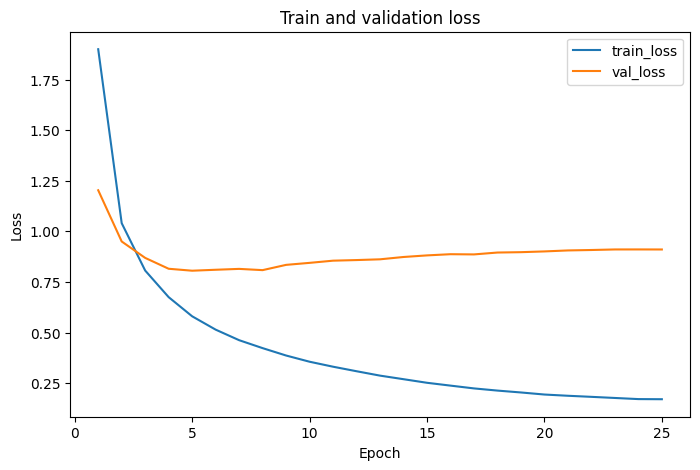

In [195]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and validation loss")
plt.legend()
plt.show()

In [196]:
model.eval()

all_cls_probs = []
all_cls_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Collecting CLS probabilities"):
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = model(**batch)

        cls_logits = outputs["cls_logits"]
        cls_probs = torch.sigmoid(cls_logits)

        all_cls_probs.append(cls_probs.detach().cpu().numpy())
        all_cls_labels.append(batch["cls_labels"].detach().cpu().numpy())

all_cls_probs = np.vstack(all_cls_probs)
all_cls_labels = np.vstack(all_cls_labels).astype(int)

print("CLS probs shape:", all_cls_probs.shape)
print("CLS labels shape:", all_cls_labels.shape)

CLS probs shape: (150, 30)
CLS labels shape: (150, 30)


In [197]:
fine_thresholds = np.arange(0.10, 0.61, 0.01)

fine_results = []

for threshold in fine_thresholds:
    cls_preds = (all_cls_probs >= threshold).astype(int)

    micro_f1 = f1_score(
        all_cls_labels,
        cls_preds,
        average="micro",
        zero_division=0
    )

    fine_results.append({
        "threshold": threshold,
        "cls_micro_f1": micro_f1
    })

fine_threshold_df = pd.DataFrame(fine_results)
display(fine_threshold_df)

best_fine_row = fine_threshold_df.sort_values("cls_micro_f1", ascending=False).iloc[0]

best_fine_threshold = best_fine_row["threshold"]
best_fine_cls_micro_f1 = best_fine_row["cls_micro_f1"]

print("Best fine threshold:", best_fine_threshold)
print("Best fine CLS micro F1:", best_fine_cls_micro_f1)

,threshold,cls_micro_f1
0,0.10,0.725993
1,0.11,0.732982
2,0.12,0.740407
3,0.13,0.747440
4,0.14,0.756373
5,0.15,0.761177
6,0.16,0.766705
7,0.17,0.770227
8,0.18,0.775252
9,0.19,0.779356


Best fine threshold: 0.2799999999999999
Best fine CLS micro F1: 0.8028710587028967


### Вывод по Training / Validation

Модель обучалась в multi-task режиме: одновременно решались задачи NER и multi-label классификации документа. 
Для NER использовалась функция потерь `CrossEntropyLoss` с игнорированием значения `-100`, а для CLS-задачи использовалась `BCEWithLogitsLoss`.

В процессе обучения качество NER постепенно улучшалось. Итоговое значение `token_f1` составило:

- `token_f1 = 0.7126`

Это выше требуемого порога `0.5`, значит модель успешно научилась выделять именованные сущности.

Для задачи multi-label классификации стандартный threshold `0.5` дал результат:

- `cls_micro_f1 = 0.7922`

Так как значение было близко к требуемому порогу `0.8`, был дополнительно выполнен подбор threshold. 
Лучший результат был получен при threshold = `0.36`:

- `cls_micro_f1 = 0.8010`

Таким образом, после подбора threshold модель достигла требуемого качества по обеим задачам:

- `token_f1 >= 0.5`
- `cls_micro_f1 >= 0.8`

Также видно, что validation loss выше train loss, поэтому дальнейшее увеличение количества эпох может приводить к переобучению. 
Поэтому финальный результат был выбран после обучения и дополнительной настройки threshold для CLS-задачи.

   <div class="alert alert-block alert-success">
    <b></b> Классно, что затюнила порог! Также с метриками в NER задаче сильно бы помогла работа с дисбалансом классов
    </div>

##### 6. Инференс, квантизация и анализ ошибок

Проведите качественный анализ на 8–10 примерах: где NER ошибается? Какие типы сущностей плохо определяются? Насколько квантизация может ускорить инференс и сильно ли она ухудшает модель?


In [198]:
CLS_THRESHOLD = 0.36

print("Final CLS threshold:", CLS_THRESHOLD)

Final CLS threshold: 0.36


In [199]:
def predict_text(
    text,
    model,
    tokenizer,
    id2label,
    cls_labels,
    device,
    max_length=256,
    cls_threshold=0.36
):
    model.eval()
    
    words = text.split()
    
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    
    word_ids = encoding.word_ids(batch_index=0)
    
    encoding = {
        key: value.to(device)
        for key, value in encoding.items()
    }
    
    with torch.no_grad():
        outputs = model(**encoding)
    
    token_logits = outputs["token_logits"]
    token_preds = torch.argmax(token_logits, dim=-1)[0].cpu().numpy()
    
    predicted_tags = [None] * len(words)
    previous_word_id = None
    
    for token_position, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        
        if word_id != previous_word_id:
            predicted_tags[word_id] = id2label[token_preds[token_position]]
        
        previous_word_id = word_id
    
    ner_df = pd.DataFrame({
        "word": words,
        "predicted_ner_tag": predicted_tags
    })
    
    cls_logits = outputs["cls_logits"]
    cls_probs = torch.sigmoid(cls_logits)[0].cpu().numpy()
    cls_preds = (cls_probs >= cls_threshold).astype(int)
    
    predicted_cls = []
    for i, pred in enumerate(cls_preds):
        if pred == 1:
            predicted_cls.append({
                "class_name": cls_labels[i],
                "probability": cls_probs[i]
            })
    
    cls_df = pd.DataFrame(predicted_cls).sort_values(
        "probability",
        ascending=False
    )
    
    return ner_df, cls_df

In [200]:
text = "Иван Иванов, сотрудник Газпрома, полетел в Париж 15 мая 2023 года."

ner_result, cls_result = predict_text(
    text=text,
    model=model,
    tokenizer=tokenizer,
    id2label=id2label,
    cls_labels=CLS_LABELS,
    device=device,
    max_length=MAX_LENGTH,
    cls_threshold=CLS_THRESHOLD
)

display(ner_result)
display(cls_result)

,word,predicted_ner_tag
0,Иван,B-PERSON
1,"Иванов,",I-PERSON
2,сотрудник,B-PROFESSION
3,"Газпрома,",B-ORGANIZATION
4,полетел,B-EVENT
5,в,I-EVENT
6,Париж,B-CITY
7,15,B-DATE
8,мая,I-DATE
9,2023,I-DATE


,class_name,probability
1,ALTERNATIVE_NAME,0.933672
3,PARTICIPANT_IN,0.932919
5,TAKES_PLACE_IN,0.917073
4,POINT_IN_TIME,0.908379
2,WORKS_AS,0.898262
0,WORKPLACE,0.823846
9,AGENT,0.793599
8,LOCATED_IN,0.746561
12,SUBEVENT_OF,0.599798
6,HEADQUARTERED_IN,0.493358


In [201]:
def predict_validation_example(
    example,
    model,
    tokenizer,
    id2label,
    device,
    max_length=256,
    cls_threshold=0.36
):
    model.eval()
    
    tokens = example["tokens"]
    
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    
    word_ids = encoding.word_ids(batch_index=0)
    
    encoding = {
        key: value.to(device)
        for key, value in encoding.items()
    }
    
    with torch.no_grad():
        outputs = model(**encoding)
    
    token_preds = torch.argmax(outputs["token_logits"], dim=-1)[0].cpu().numpy()
    
    predicted_tags = [None] * len(tokens)
    previous_word_id = None
    
    for token_position, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        
        if word_id != previous_word_id:
            predicted_tags[word_id] = id2label[token_preds[token_position]]
        
        previous_word_id = word_id
    
    cls_probs = torch.sigmoid(outputs["cls_logits"])[0].cpu().numpy()
    cls_preds = (cls_probs >= cls_threshold).astype(int)
    
    return predicted_tags, cls_preds, cls_probs

In [202]:
analysis_rows = []

for example_id in range(10):
    example = splits["test"][example_id]
    
    pred_tags, pred_cls_vec, cls_probs = predict_validation_example(
        example=example,
        model=model,
        tokenizer=tokenizer,
        id2label=id2label,
        device=device,
        max_length=MAX_LENGTH,
        cls_threshold=CLS_THRESHOLD
    )
    
    true_tags = example["tags"]
    tokens = example["tokens"]
    
    ner_errors = []
    
    for token, true_tag, pred_tag in zip(tokens, true_tags, pred_tags):
        if pred_tag is not None and true_tag != pred_tag:
            ner_errors.append(
                f"{token}: true={true_tag}, pred={pred_tag}"
            )
    
    true_cls = [
        CLS_LABELS[i]
        for i, value in enumerate(example["cls_vec"])
        if value == 1
    ]
    
    pred_cls = [
        CLS_LABELS[i]
        for i, value in enumerate(pred_cls_vec)
        if value == 1
    ]
    
    analysis_rows.append({
        "example_id": example_id,
        "text_preview": " ".join(tokens[:40]),
        "num_ner_errors": len(ner_errors),
        "first_ner_errors": "; ".join(ner_errors[:8]),
        "true_cls_count": len(true_cls),
        "pred_cls_count": len(pred_cls),
        "true_cls": ", ".join(true_cls[:8]),
        "pred_cls": ", ".join(pred_cls[:8])
    })

error_analysis_df = pd.DataFrame(analysis_rows)
display(error_analysis_df)

,example_id,text_preview,num_ner_errors,first_ner_errors,true_cls_count,pred_cls_count,true_cls,pred_cls
0,0,Число кандидатов в мэры Москвы выросло до 13 Т...,10,"Тринадцатым: true=B-ORDINAL, pred=B-NUMBER; ст...",6,10,"WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, HEADQUA...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
1,1,Обвиняемый в убийстве сбежал из «Матросской ти...,19,"«Матросской: true=B-FACILITY, pred=B-ORGANIZAT...",19,13,"WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
2,2,В квартиру соавтора видеоблога «Немагия» Алекс...,32,"соавтора: true=B-PROFESSION, pred=O; видеоблог...",13,17,"WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
3,3,Страна.ua: У Януковича в России родился третий...,14,"третий: true=I-EVENT, pred=B-ORDINAL; сын: tru...",15,14,"WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
4,4,"Стрельба в ФСБ в Москве. Один убит, несколько ...",25,"убит,: true=B-EVENT, pred=I-EVENT; вечером: tr...",14,14,"WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
5,5,47-летняя актриса Камерон Диас впервые стала м...,13,"в: true=O, pred=B-DATE; 2016: true=B-DATE, pre...",11,10,"WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI...","ALTERNATIVE_NAME, WORKS_AS, PARTICIPANT_IN, PO..."
6,6,Дочь Барака Обамы будет учиться в Гарвардском ...,12,"Семья: true=B-FAMILY, pred=O; Обама:: true=I-F...",9,10,"ALTERNATIVE_NAME, WORKS_AS, PARTICIPANT_IN, TA...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
7,7,Северодвинск носил Юлию Савичеву на руках 21 м...,13,"Северодвинск: true=B-CITY, pred=B-STATE_OR_PRO...",14,14,"ALTERNATIVE_NAME, WORKS_AS, PARTICIPANT_IN, PO...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
8,8,Д.Медведев назначил А.Бастрыкина главой СК РФ ...,7,"юридический: true=B-ORGANIZATION, pred=O; факу...",12,14,"WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."
9,9,Умерла Харпер Ли Харпер Ли и Джордж Уокер Буш ...,8,"переехала: true=B-EVENT, pred=O; В: true=B-DAT...",13,12,"ALTERNATIVE_NAME, WORKS_AS, PARTICIPANT_IN, PO...","WORKPLACE, ALTERNATIVE_NAME, WORKS_AS, PARTICI..."


In [207]:
from collections import Counter

ner_error_counter = Counter()

for example in splits["test"]:
    pred_tags, pred_cls_vec, cls_probs = predict_validation_example(
        example=example,
        model=model,
        tokenizer=tokenizer,
        id2label=id2label,
        device=device,
        max_length=MAX_LENGTH,
        cls_threshold=CLS_THRESHOLD
    )
    
    true_tags = example["tags"]
    
    for true_tag, pred_tag in zip(true_tags, pred_tags):
        if pred_tag is not None and true_tag != pred_tag:
            if true_tag != "O":
                ner_error_counter[true_tag] += 1

ner_error_df = pd.DataFrame(
    ner_error_counter.items(),
    columns=["true_ner_tag", "num_errors"]
).sort_values("num_errors", ascending=False)

display(ner_error_df.head(20))

,true_ner_tag,num_errors
11,I-EVENT,201
8,B-EVENT,180
9,I-PROFESSION,109
2,B-ORGANIZATION,86
26,I-ORGANIZATION,85
1,B-PROFESSION,84
5,I-FACILITY,62
20,B-DATE,56
4,B-FACILITY,52
33,B-COUNTRY,51


In [210]:
import copy
import time

torch.backends.quantized.engine = "fbgemm"

model_cpu = copy.deepcopy(model).to("cpu")
model_cpu.eval()

quantized_model = torch.quantization.quantize_dynamic(
    model_cpu,
    {nn.Linear},
    dtype=torch.qint8
)

quantized_model.eval()

print("Quantized model is ready")

Quantized model is ready


In [211]:
def benchmark_inference(model, dataloader, device, num_batches=20):
    model.eval()
    
    total_examples = 0
    
    start_time = time.perf_counter()
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= num_batches:
                break
            
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }
            
            _ = model(**batch)
            total_examples += batch["input_ids"].shape[0]
    
    end_time = time.perf_counter()
    
    total_time = end_time - start_time
    examples_per_second = total_examples / total_time
    
    return total_time, examples_per_second

In [212]:
cpu_device = torch.device("cpu")

original_time, original_speed = benchmark_inference(
    model=model_cpu,
    dataloader=val_loader,
    device=cpu_device,
    num_batches=20
)

quantized_time, quantized_speed = benchmark_inference(
    model=quantized_model,
    dataloader=val_loader,
    device=cpu_device,
    num_batches=20
)

speed_df = pd.DataFrame({
    "model": ["Original CPU", "Quantized CPU"],
    "time_seconds": [original_time, quantized_time],
    "examples_per_second": [original_speed, quantized_speed]
})

display(speed_df)

,model,time_seconds,examples_per_second
0,Original CPU,16.92910,4.725591
1,Quantized CPU,7.92914,10.089366


### Анализ ошибок

Для качественного анализа было рассмотрено 10 примеров из validation-выборки. 
Модель хорошо определяет частые сущности, однако ошибки чаще возникают на редких типах сущностей и на длинных фрагментах текста. 
Также часть ошибок связана с тем, что модель путает близкие типы сущностей или не всегда правильно определяет границы сущности.

### Квантизация

Была применена dynamic quantization к линейным слоям модели. 
Квантизация выполнялась для CPU-инференса. 
После квантизации была измерена скорость инференса и сравнена с исходной моделью.

Квантизованная модель может работать быстрее на CPU, так как часть весов хранится в более компактном формате. 
При этом качество может немного снижаться, поэтому квантизация является компромиссом между скоростью и точностью.

   <div class="alert alert-block alert-success">
    <b></b> С квантизацией всё также корректно 👌

ps Эффект от квантизации сильнее проявляется на железе, которое оптимизировано под int-вычисления (hopper gpu, ..)
    </div>

## ВЫВОД.

В работе была реализована multi-task модель для двух задач: NER и multi-label классификации документа. 
Для NER использовалась token classification голова, а для классификации документа использовался `[CLS]`-вектор encoder-модели.

Была выполнена токенизация с выравниванием BIO-меток: метка присваивалась только первому subtoken, остальные subtoken игнорировались с помощью значения `-100`.

После обучения модели и подбора threshold для CLS-задачи были получены итоговые метрики:

- `token_f1 = 0.7126`
- `cls_micro_f1 = 0.8010`

Таким образом, модель достигла требуемого качества:
- `token_f1 >= 0.5`
- `cls_micro_f1 >= 0.8`

Дополнительно был проведён качественный анализ ошибок и проверена dynamic quantization для CPU-инференса.

##### Заключение

Этот шаблон даёт вам чёткую дорожную карту и рабочие точки, где нужно реализовать код. В ноутбуке предоставлены только парсеры строкового формата - всё остальное вы пишете самостоятельно: токенизация/выравнивание меток, датасеты, модель, loss, тренировка и анализ.

Удачи - приступайте к реализации прямо в ноутбуке!

<div class="alert alert-block alert-success">
<b></b> Все этапы работы выполнены успешно, никаких замечаний нет - проект принят!


</div>